# **Business Case 1: Segmenting Clients**

In this executable notebook you have a logical track of the work, with working code snippets, some method suggestions (absolutely non-binding). Basically: examples of what you can do.


Remember: when it comes to data modeling, there is almost never a "one size fits all", thus you can take various ways to solve the problem.


So feel free to take this code as a draft, change it, even significantly, following your modeling vision. Feel free to explore data and methods and gain experience (yes, even getting it wrong and getting results you don't like - it's quite normal in real applications). You will find some **"HINTS"**: they are just suggestions for you - I mean, you don't have to follow all the suggestions, and if you want you can follow your inspiration, my "Hints" are just ideas...

Remember: **experimenting with data - that's the purpose of this Machine Learning Lab.**

<br>

## Goal

Here we have a random extraction of **a (real-world) dataset made up of a bank's customers**. The data is **anonymous, mostly clean and normalized in [0, 1]**.

We intend to **segment these customers using Data Science techniques** (essentially Unsupervised Machine Learning); this is a segmentation carried out from the perspective of the financial services sector.


The **dataset is called "Dataset1_BankClients"** and is saved as a .xls file.

<br>

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
import gower
import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)

In [3]:
# Drop the column by its actual name (e.g., 'ID' or the actual name of the column)
data = data.drop(columns=['ID'])  # Replace 'ID' with the actual column name to drop

# Let's inspect the first 5 record
data.head()



,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data
We extract the variables of interest, also dividing into:
* **Numerical**.
* **Categorical** (excluding the ID, which is not informative at this level).


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

## Outlier Analysis

In [4]:
def find_outliers_selective(df, columns_to_check):
    """
    df: Your pandas DataFrame
    columns_to_check: List of strings (names of continuous numerical columns)
    """
    rows_to_drop = set()
    
    for col in columns_to_check:
        data = df[col].values
        mean, std = data.mean(), data.std()
        
        # 3-sigma rule
        lower, upper = mean - 3*std, mean + 3*std
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        if not outliers.empty:
            print(f"Feature '{col}' has {len(outliers)} outliers.")
            rows_to_drop.update(outliers.index.tolist())
            
    # Drop rows by index
    df_cleaned = df.drop(index=list(rows_to_drop))
    print(f"\nDropped {len(rows_to_drop)} total rows.")
    return df_cleaned

# Usage: Only pass Age or Family Members, NOT Gender/Occupation/Percentiles
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
continuous_cols =  [col for col in data.columns if col not in categorical_cols]
data = find_outliers_selective(data, continuous_cols)

Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.


In [10]:
# ==========================================
# OBJECTIVE 1: FAMD PIPELINE (Cross-Selling)
# ==========================================

# 1. Isolate the exact mixed dataset for Objective 1
active_cols = ['Wealth', 'Income', 'Debt', 'Saving','Luxury' ,'LifeStyle','Investments']
#active_cols = ['LifeStyle', 'Luxury', 'Investments', 'Saving','ESG']
df_active_mixed = data[active_cols].copy()

# Ensure 'Investments' is treated as a category so FAMD knows what to do
df_active_mixed['Investments'] = df_active_mixed['Investments'].astype(str)

print("Original Mixed Dataset:")
display(df_active_mixed.head(5))

# 2. Initialize and Fit FAMD
# We reduce the 6 mixed variables down to 5 purely continuous latent dimensions
famd = prince.FAMD(
    n_components=4,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Transform the mixed data into pure continuous coordinates
X_famd = famd.fit_transform(df_active_mixed)
X_famd.columns = ['Dim_1', 'Dim_2', 'Dim_3','Dim_4']

print("\nFAMD Continuous Coordinates (Ready for Clustering):")
display(X_famd.head(3))

# 3. Check the Variance Explained
# This proves to the professor that your dimensions captured the actual data!
# 3. Check the Variance Explained (Updated for Prince v0.13+)
try:
    # Newer versions use this attribute
    explained_variance = famd.percentage_of_variance_
except AttributeError:
    # Fallback just in case
    explained_variance = famd.explained_inertia_

# The newer library outputs actual percentages (e.g., 45.2 instead of 0.452)
# We do a quick check to see if we need to multiply by 100
total_var = sum(explained_variance)
if total_var <= 1.0:
    total_var *= 100
    explained_variance = [v * 100 for v in explained_variance]

print(f"\nTotal Variance Explained by 4 Dimensions: {total_var:.2f}%")

Original Mixed Dataset:


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
0,0.702786,0.668046,0.262070,0.283222,0.897369,0.607877,1
1,0.915043,0.858453,0.730430,0.821590,0.913729,0.862271,3
2,0.898316,0.926818,0.441272,0.503790,0.765199,0.755404,3
3,0.423180,0.538797,0.600401,0.691240,0.517209,0.334432,2
4,0.731404,0.806659,0.831449,0.615916,0.611610,0.908878,2



FAMD Continuous Coordinates (Ready for Clustering):


,Dim_1,Dim_2,Dim_3,Dim_4
0,-0.640950,2.206368,-0.121340,-0.171734
1,-3.923503,-0.139871,-0.123500,-0.232439
2,-2.450747,1.272439,0.267361,0.218499



Total Variance Explained by 4 Dimensions: 72.79%


Silhouette Score for k=4: 0.262


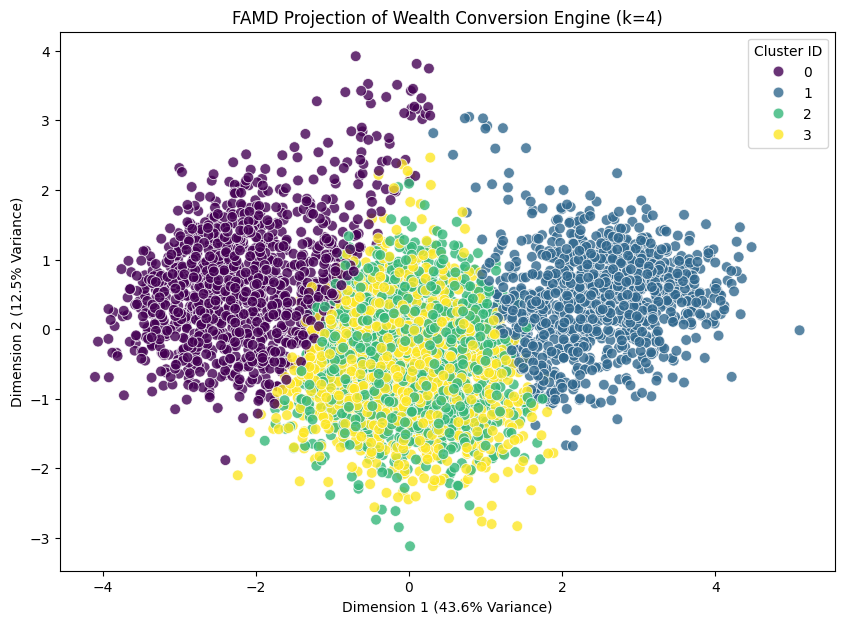


--- CLUSTER PROFILES (The Business Truth) ---


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
Cluster_ID,,,,,,,
0,0.79,0.79,0.56,0.58,0.76,0.71,3
1,0.37,0.37,0.16,0.30,0.24,0.27,2
2,0.59,0.65,0.40,0.61,0.44,0.34,3
3,0.55,0.48,0.55,0.57,0.44,0.52,3


In [21]:
# 4. Standard Euclidean Clustering on the FAMD dimensions
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_famd)

sil_score = silhouette_score(X_famd, cluster_labels)
print(f"Silhouette Score for k={optimal_k}: {sil_score:.3f}")

# 5. Plot the Manifold (Updated labels)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_famd['Dim_1'], 
    y=X_famd['Dim_2'], 
    hue=cluster_labels, 
    palette='viridis', 
    s=60, alpha=0.8
)

plt.title(f'FAMD Projection of Wealth Conversion Engine (k={optimal_k})')
plt.xlabel(f'Dimension 1 ({explained_variance[0]:.1f}% Variance)')
plt.ylabel(f'Dimension 2 ({explained_variance[1]:.1f}% Variance)')
plt.legend(title='Cluster ID')
plt.show()

# 6. Profile the Clusters to find the Business Target
df_active_mixed['Cluster_ID'] = cluster_labels
print("\n--- CLUSTER PROFILES (The Business Truth) ---")
display(df_active_mixed.groupby('Cluster_ID').agg({
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'Luxury': 'mean',
    'LifeStyle':'mean',
    'Investments': lambda x: x.mode()[0]
}).round(2))

In [22]:
# 1. Extract the column contributions to each FAMD dimension
contributions = famd.column_contributions_.style.format("{:.2%}")
print("--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---")
display(contributions)

# 2. Extract column correlations (for continuous variables)
# This tells you the direction (positive/negative correlation)
try:
    correlations = famd.column_correlations(df_active_mixed)
    print("\n--- FEATURE CORRELATIONS WITH DIMENSIONS ---")
    display(correlations.round(3))
except AttributeError:
    pass # Older versions of Prince might handle this differently

--- FEATURE CONTRIBUTIONS TO FAMD DIMENSIONS ---


component,0,1,2,3
variable,,,,
Wealth,17.38%,2.12%,29.83%,30.96%
Income,17.84%,3.33%,2.91%,63.81%
Debt,15.52%,19.86%,21.92%,0.77%
Saving,12.17%,46.43%,7.61%,0.16%
Luxury,19.57%,11.14%,0.07%,0.02%
LifeStyle,16.60%,12.32%,29.16%,4.07%
Investments,1.84%,9.58%,16.99%,0.43%


NotImplementedError: FAMD inherits from PCA, but this method is not implemented yet

In [23]:
# df_active_original should be your raw Wealth, Income, Debt, Saving, Investments data
df_active_mixed['Cluster_ID'] = cluster_labels

print("--- THE FINANCIAL PERSONAS (Averages by Cluster) ---")
profile_active = df_active_mixed.groupby('Cluster_ID').agg({
    'Wealth': 'mean',
    'Income': 'mean',
    'Debt': 'mean',
    'Saving': 'mean',
    'Luxury': 'mean',
    'LifeStyle': 'mean',
    'Investments': lambda x: x.mode()[0] # The most frequent investment level
}).round(1)

display(profile_active)

--- THE FINANCIAL PERSONAS (Averages by Cluster) ---


,Wealth,Income,Debt,Saving,Luxury,LifeStyle,Investments
Cluster_ID,,,,,,,
0,0.8,0.8,0.6,0.6,0.8,0.7,3
1,0.4,0.4,0.2,0.3,0.2,0.3,2
2,0.6,0.7,0.4,0.6,0.4,0.3,3
3,0.5,0.5,0.6,0.6,0.4,0.5,3


In [31]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_cluster_id = 0
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

# ... (Insert the distribution code from the previous step here)

--- MARKETING PROFILE FOR TARGET CLUSTER 0 ---
Average Age: 50.2
Most common Gender: 0
Most common familySize : 1
Digital Propensity: 0.74
BankFriend Propensity: 0.74
Financial Education: 0.69
Most common Job: 2
Most common Area: 1
Most common CitySize: 3
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 0 ---

--- Gender Distribution ---
Gender
0    54.6%
1    45.4%
Name: proportion, dtype: object

--- Job Distribution ---
Job
2    77.3%
1    11.8%
3     4.6%
5     4.0%
4     2.3%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    80.2%
2    12.9%
3     6.9%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
3    58.4%
2    31.3%
1    10.3%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    40.5%
2    24.9%
3    17.1%
4    14.3%
5     2.2%
6     1.1%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  50.221026  0.744769    0.735329  0.692859
min   19.00

In [ ]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 1
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)



--- MARKETING PROFILE FOR TARGET CLUSTER 1 ---
Average Age: 75.4
Most common Gender: 1
Most common familySize : 1
Digital Propensity: 0.34
BankFriend Propensity: 0.60
Financial Education: 0.35
Most common Job: 5
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 1 ---

--- Gender Distribution ---
Gender
1    55.2%
0    44.8%
Name: proportion, dtype: object

--- Job Distribution ---
Job
5    58.8%
2    19.8%
1    18.4%
4     2.3%
3     0.7%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    66.1%
2    23.6%
3    10.3%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    47.8%
1    43.1%
3     9.1%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    33.8%
2    27.7%
3    19.8%
4    14.6%
5     2.7%
6     1.3%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  75.353748  0.344501    0.596941  0.349964
min   19.00

In [34]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 2
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 2 ---
Average Age: 60.8
Most common Gender: 1
Most common familySize : 1
Digital Propensity: 0.48
BankFriend Propensity: 0.59
Financial Education: 0.48
Most common Job: 2
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 2 ---

--- Gender Distribution ---
Gender
1    56.9%
0    43.1%
Name: proportion, dtype: object

--- Job Distribution ---
Job
2    76.6%
1    12.0%
5     7.4%
3     2.3%
4     1.6%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    71.7%
2    15.9%
3    12.3%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    44.5%
1    40.1%
3    15.5%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    28.4%
2    22.0%
3    21.6%
4    13.6%
5     8.0%
6     6.6%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  60.797656  0.475658    0.585307  0.481998
min   19.00

In [ ]:
# Merge the cluster labels onto your quarantined demographic/psychographic data
df_passive_obj1 = data.drop(columns=active_cols).copy()
df_passive_obj1['Cluster_ID'] = cluster_labels

# Isolate your target cluster (replace '2' with whatever ID you found in Step 2)
target_cluster_id = 3
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

print(f"--- MARKETING PROFILE FOR TARGET CLUSTER {target_cluster_id} ---")
print(f"Average Age: {target_profile['Age'].mean():.1f}")
print(f"Most common Gender: {target_profile['Gender'].mode()[0]}")
print(f"Most common familySize : {target_profile['FamilySize'].mode()[0]}")
print(f"Digital Propensity: {target_profile['Digital'].mean():.2f}")
print(f"BankFriend Propensity: {target_profile['BankFriend'].mean():.2f}")
print(f"Financial Education: {target_profile['FinEdu'].mean():.2f}")
print(f"Most common Job: {target_profile['Job'].mode()[0]}")
print(f"Most common Area: {target_profile['Area'].mode()[0]}")
print(f"Most common CitySize: {target_profile['CitySize'].mode()[0]}")


print(f"--- DETAILED DISTRIBUTION FOR TARGET CLUSTER {target_cluster_id} ---\n")

# 1. Categorical Distributions (Gender, Job, Area, CitySize, FamilySize)
cat_cols = ['Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

for col in cat_cols:
    print(f"--- {col} Distribution ---")
    # value_counts(normalize=True) gives proportions; multiplying by 100 gives percentages
    dist = target_profile[col].value_counts(normalize=True) * 100
    print(dist.map('{:.1f}%'.format))
    print("")

# 2. Numerical Distributions (Age, Digital, BankFriend, FinEdu)
# Using .describe() gives you the mean, min, max, and quartiles
num_cols = ['Age', 'Digital', 'BankFriend', 'FinEdu']
print("--- Numerical Feature Summary ---")
print(target_profile[num_cols].describe().loc[['mean', 'min', '50%', 'max']])



# Calculate total rows in the entire dataset
total_count = len(df_passive_obj1)

# Isolate your target cluster
target_profile = df_passive_obj1[df_passive_obj1['Cluster_ID'] == target_cluster_id]

# Calculate size of target cluster
cluster_count = len(target_profile)
cluster_pct = (cluster_count / total_count) * 100

print(f"--- VOLUME SUMMARY FOR CLUSTER {target_cluster_id} ---")
print(f"Total People in Cluster: {cluster_count}")
print(f"Percentage of Total Base: {cluster_pct:.1f}%")
print("-" * 40)

--- MARKETING PROFILE FOR TARGET CLUSTER 3 ---
Average Age: 57.4
Most common Gender: 1
Most common familySize : 1
Digital Propensity: 0.53
BankFriend Propensity: 0.57
Financial Education: 0.51
Most common Job: 2
Most common Area: 1
Most common CitySize: 2
--- DETAILED DISTRIBUTION FOR TARGET CLUSTER 3 ---

--- Gender Distribution ---
Gender
1    53.6%
0    46.4%
Name: proportion, dtype: object

--- Job Distribution ---
Job
2    81.3%
1     7.8%
5     5.0%
3     3.6%
4     2.3%
Name: proportion, dtype: object

--- Area Distribution ---
Area
1    71.5%
2    14.5%
3    14.0%
Name: proportion, dtype: object

--- CitySize Distribution ---
CitySize
2    41.7%
1    38.5%
3    19.8%
Name: proportion, dtype: object

--- FamilySize Distribution ---
FamilySize
1    27.2%
2    22.3%
3    21.0%
4    15.3%
5     8.0%
6     6.1%
Name: proportion, dtype: object

--- Numerical Feature Summary ---
            Age   Digital  BankFriend    FinEdu
mean  57.420269  0.530242    0.568224  0.507159
min   19.00